# Vehicles Insurance Claims Analysis

### Business Objective:

* Analyze Vehicles insurance data to identify claim trends, premium performance, high-risk vehicles, and provide insights that help improve business decisions 

01_Data_Understanding.ipynb

02_Data_Cleaning.ipynb

03_Feature_Engineering.ipynb

04_EDA.ipynb

05_Business_Insights.ipynb

In [1]:
# Import required libraries for data analysis and visualization.

import numpy as np                 # Numerical operations
import pandas as pd                # Data manipulation
import matplotlib.pyplot as plt    # Data visualization
import seaborn as sns              # Statistical visualization

In [2]:
data = pd.read_csv('Vehicle_Insurance.csv')    

In [3]:
data.head(5)   

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category
0,0,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
1,0,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
2,0,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
3,0,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
4,0,08/08/2013,2013,07/08/2014,2014,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid


In [4]:
copy_data = data.copy()   # Backup data safe 

In [5]:
data = copy_data           

#### Phase 1: Data Understanding

In [6]:
data.shape 

(293417, 18)

In [8]:
data.columns 

Index(['Gender', 'Policy_Start', 'Policy_Year', 'Policy_End',
       'Policy_End_Year', 'Insurance_Types', 'Vehicle_Values', 'Premium',
       'Vehicle_ID', 'Product_Year', 'Num_Seat', 'Capacity', 'Vehicle_Types',
       'Engine_Size_Ton', 'Brand', 'Usage_Types', 'Claim_Amount',
       'Claim_Category'],
      dtype='object')

In [9]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293417 entries, 0 to 293416
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Gender           293417 non-null  int64  
 1   Policy_Start     293417 non-null  object 
 2   Policy_Year      293417 non-null  int64  
 3   Policy_End       293417 non-null  object 
 4   Policy_End_Year  293417 non-null  int64  
 5   Insurance_Types  293417 non-null  int64  
 6   Vehicle_Values   293417 non-null  float64
 7   Premium          293409 non-null  float64
 8   Vehicle_ID       293417 non-null  int64  
 9   Product_Year     293311 non-null  float64
 10  Num_Seat         293277 non-null  float64
 11  Capacity         293417 non-null  float64
 12  Vehicle_Types    293417 non-null  object 
 13  Engine_Size_Ton  293417 non-null  float64
 14  Brand            293417 non-null  object 
 15  Usage_Types      293417 non-null  object 
 16  Claim_Amount     293417 non-null  floa

In [10]:
data.describe() 

,Gender,Policy_Year,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Engine_Size_Ton,Claim_Amount
count,293417.000000,293417.000000,293417.000000,293417.000000,2.934170e+05,293409.000000,2.934170e+05,293311.000000,293277.000000,293417.000000,293417.000000,2.934170e+05
mean,0.510032,2012.359083,2013.271665,1201.714243,4.146758e+05,6477.284624,5.000237e+09,2001.394738,6.182657,468.582947,3304.309163,2.128444e+04
std,0.645339,0.992363,1.031008,0.455494,8.355149e+05,9040.684427,1.684094e+05,10.305470,13.046853,4124.866348,3499.414850,5.595337e+05
min,0.000000,2011.000000,2011.000000,1201.000000,0.000000e+00,0.000000,5.000018e+09,1950.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,2012.000000,2012.000000,1201.000000,0.000000e+00,804.850000,5.000096e+09,1995.000000,1.000000,0.000000,997.000000,0.000000e+00
50%,0.000000,2012.000000,2013.000000,1202.000000,2.000000e+05,3156.030000,5.000198e+09,2005.000000,4.000000,1.000000,2494.000000,0.000000e+00
75%,1.000000,2013.000000,2014.000000,1202.000000,5.856992e+05,8293.213000,5.000344e+09,2010.000000,4.000000,11.000000,4164.000000,0.000000e+00
max,2.000000,2014.000000,2015.000000,1204.000000,2.500000e+08,227278.880000,5.000949e+09,2018.000000,199.000000,1000000.000000,20000.000000,1.524458e+08


In [11]:
data.tail()

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category
293412,2,11/08/2012,2012,10/08/2013,2013,1201,0.0,577.700,5000047311,1985.0,4.0,0.0,Automobile,1295.0,TOYOTA,Private,0.0,No Claim
293413,2,11/08/2011,2011,10/08/2012,2012,1201,0.0,695.318,5000047311,1985.0,4.0,0.0,Automobile,1295.0,TOYOTA,Private,0.0,No Claim
293414,2,01/06/2013,2013,31/05/2014,2014,1201,250000.0,4778.450,5000949222,1993.0,4.0,0.0,Automobile,1295.0,TOYOTA,Private,0.0,No Claim
293415,0,08/07/2012,2012,07/07/2013,2013,1202,0.0,1057.427,5000049231,2017.0,2.0,0.0,Truck,4570.0,ISUZU,General Cartage,0.0,No Claim
293416,0,08/07/2011,2011,07/07/2012,2012,1202,0.0,1001.537,5000049231,2017.0,2.0,0.0,Truck,4570.0,ISUZU,General Cartage,0.0,No Claim


In [12]:
data.sample()

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category
194908,1,11/02/2012,2012,10/02/2013,2013,1202,0.0,1949.7,5000265154,1969.0,11.0,0.0,Bus,2446.0,TOYOTA,Fare Paying Passengers,0.0,No Claim


#### Phase 2: Data Quality Check

In [11]:
data.isnull().sum() 

Gender               0
Policy_Start         0
Policy_Year          0
Policy_End           0
Policy_End_Year      0
Insurance_Types      0
Vehicle_Values       0
Premium              8
Vehicle_ID           0
Product_Year       106
Num_Seat           140
Capacity             0
Vehicle_Types        0
Engine_Size_Ton      0
Brand                0
Usage_Types          0
Claim_Amount         0
Claim_Category       0
dtype: int64

In [14]:
data.duplicated().sum() 

71

In [12]:
data.drop_duplicates(inplace = True)  #Remove duplicate data

In [13]:
data.duplicated().sum() 

0

In [17]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 293346 entries, 0 to 293416
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Gender           293346 non-null  int64  
 1   Policy_Start     293346 non-null  object 
 2   Policy_Year      293346 non-null  int64  
 3   Policy_End       293346 non-null  object 
 4   Policy_End_Year  293346 non-null  int64  
 5   Insurance_Types  293346 non-null  int64  
 6   Vehicle_Values   293346 non-null  float64
 7   Premium          293338 non-null  float64
 8   Vehicle_ID       293346 non-null  int64  
 9   Product_Year     293240 non-null  float64
 10  Num_Seat         293206 non-null  float64
 11  Capacity         293346 non-null  float64
 12  Vehicle_Types    293346 non-null  object 
 13  Engine_Size_Ton  293346 non-null  float64
 14  Brand            293346 non-null  object 
 15  Usage_Types      293346 non-null  object 
 16  Claim_Amount     293346 non-null  float64
 

In [18]:
data.dtypes 

Gender               int64
Policy_Start        object
Policy_Year          int64
Policy_End          object
Policy_End_Year      int64
Insurance_Types      int64
Vehicle_Values     float64
Premium            float64
Vehicle_ID           int64
Product_Year       float64
Num_Seat           float64
Capacity           float64
Vehicle_Types       object
Engine_Size_Ton    float64
Brand               object
Usage_Types         object
Claim_Amount       float64
Claim_Category      object
dtype: object

In [14]:
data['Gender'].unique() 

array([0, 1, 2], dtype=int64)

In [15]:
data['Gender'].value_counts() 

Gender
0    168175
1    100741
2     24430
Name: count, dtype: int64

In [21]:
### Gender is encoded as 0, 1, and 2 in the source dataset.

## Replace 0: Male, 1: Female and 2: Unknown

In [16]:
data['Gender'] = data['Gender'].replace({
                                0:"Male",
                                1:"Female",
                                2:"Unknown"
                           }) 

In [23]:
#copy_df = data.copy()   #Copy Data for backups

In [24]:
#copy_df = data

In [17]:
data.head() 

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category
0,Male,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
1,Male,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
2,Male,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
3,Male,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
4,Male,08/08/2013,2013,07/08/2014,2014,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid


In [26]:
copy_data.head(4)

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category
0,Male,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim
1,Male,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim
2,Male,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim
3,Male,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim


In [27]:
### Fill nan valu to the median

In [18]:
copy_data['Product_Year'].median() 

2005.0

In [19]:
copy_data['Product_Year'] = copy_data['Product_Year'].fillna(copy_data['Product_Year'].median()) #Fill the value to median where is null

In [20]:
copy_data['Product_Year'].isnull().sum() 

0

In [31]:
copy_data['Product_Year'].unique() 

array([2007., 2010., 1982., 2012., 1998., 1990., 2004., 2005., 2008.,
       1999., 1995., 2000., 1985., 1991., 1993., 1974., 1997., 2002.,
       2003., 2006., 1983., 1988., 1984., 2009., 2013., 1980., 1992.,
       1981., 1986., 1976., 1994., 1987., 1969., 1979., 1989., 2001.,
       1973., 1975., 1996., 2011., 1977., 2014., 1971., 1972., 2017.,
       2016., 1970., 1978., 1967., 1963., 2018., 1964., 1961., 1957.,
       1965., 1966., 1968., 2015., 1953., 1960., 1958., 1962., 1959.,
       1950., 1955., 1954., 1952., 1956., 1951.])

In [21]:
# Check High seats values   

copy_data[copy_data['Num_Seat'] > 60]   # The dataset contains many vehicles with more than 60 seats, so I kept these records for further analysis.

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category
344,Male,24/07/2013,2013,23/07/2014,2014,1202,490576.6,8711.460,5000032600,2007.0,61.0,61.0,Bus,3000.0,MERCEDES,Own service,8300.00,Claim Paid
345,Male,24/07/2012,2012,23/07/2013,2013,1202,490576.6,9101.530,5000032600,2007.0,61.0,61.0,Bus,3000.0,MERCEDES,Own service,0.00,No Claim
346,Male,24/07/2011,2011,23/07/2012,2012,1202,613220.0,8820.836,5000032600,2007.0,61.0,61.0,Bus,3000.0,MERCEDES,Own service,0.00,No Claim
701,Male,08/07/2012,2012,07/07/2013,2013,1202,360000.0,5556.400,5000032034,2011.0,175.0,2011.0,Bus,8650.0,BISHOFTU,Fare Paying Passengers,0.00,No Claim
702,Male,08/07/2011,2011,07/07/2012,2012,1202,360000.0,5292.854,5000032034,2011.0,175.0,2011.0,Bus,8650.0,BISHOFTU,Fare Paying Passengers,70815.99,Claim Paid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288039,Female,03/06/2014,2014,02/06/2015,2015,1202,2000000.0,45935.100,5000622458,2014.0,63.0,0.0,Bus,8071.0,DAWOO,Fare Paying Passengers,0.00,No Claim
292284,Female,26/06/2014,2014,23/12/2014,2014,1202,2000000.0,22601.980,5000632963,2013.0,63.0,63.0,Bus,8071.0,DAWOO,Fare Paying Passengers,0.00,No Claim
292538,Female,31/12/2013,2013,30/12/2014,2014,1202,1000000.0,24886.820,5000637417,2013.0,66.0,0.0,Bus,4164.0,TATA,Fare Paying Passengers,0.00,No Claim
293215,Female,20/04/2014,2014,19/04/2015,2015,1202,2000000.0,15590.430,5000715544,2014.0,62.0,62.0,Bus,5883.0,TATA,Fare Paying Passengers,0.00,No Claim


In [22]:
copy_data[copy_data['Num_Seat'] < 60].shape   # Vehicles with more than 60 seats were retained because they represent a considerable number of records in the dataset.

(288717, 18)

### verify the Vehicles

In [34]:
#data = data[data['Num_Seat'] > 60][['Vehicle_Types','Brand','Num_Seat','Capacity']] 

In [23]:
data1 = data[data['Num_Seat'] > 60][['Vehicle_Types','Brand','Num_Seat','Capacity']] 

In [24]:
data1.tail()  

,Vehicle_Types,Brand,Num_Seat,Capacity
288039,Bus,DAWOO,63.0,0.0
292284,Bus,DAWOO,63.0,63.0
292538,Bus,TATA,66.0,0.0
293215,Bus,TATA,62.0,62.0
293279,Bus,MERCEDES,63.0,63.0


In [37]:
#investigation = data[data['Num_Seat'] > 60][['Num_Seat','Capacity','Engine_Size_Ton','Brand']]

In [38]:
#investigation 

In [25]:
copy_data['Num_Seat'].isnull().sum() 

140

In [26]:
copy_data.head(5) 

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category
0,Male,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
1,Male,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
2,Male,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
3,Male,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
4,Male,08/08/2013,2013,07/08/2014,2014,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid


In [27]:
copy_data['Num_Seat'] = copy_data['Num_Seat'].fillna(copy_data['Num_Seat'].median()) #Fill nan value to the median

In [28]:
copy_data['Num_Seat'].isnull().sum() 

0

In [29]:
copy_data[copy_data['Num_Seat'] > 60].shape      #Check how many seats are more than 60 seat

(3711, 18)

In [30]:
(copy_data['Num_Seat'].isnull().sum() / len(copy_data)) * 100  

0.0

In [45]:
#data2 = data_backup.copy() #Backup data for safety

In [31]:
copy_data[copy_data['Num_Seat'] > 60].shape 

(3711, 18)

In [32]:
copy_data.shape

(293346, 18)

### Observateion :

* I found some buses with very high seat counts (such as 175 and 199). These values do not look realistic, so I treated them as data quality issues and removed them from the dataset.

In [33]:
# Keep only records where Num_Seat is 60 or less, then reset the index.
copy_data = copy_data[copy_data['Num_Seat'] <= 60].reset_index(drop=True) 

In [34]:
copy_data[copy_data['Num_Seat'] <= 60].shape

(289635, 18)

In [35]:
copy_data[copy_data['Num_Seat'] > 60].shape  # Removed all the data where was more than 60 seats

(0, 18)

In [36]:
copy_data[copy_data['Num_Seat'] <= 60].shape

(289635, 18)

In [37]:
copy_data[copy_data['Num_Seat'] <= 60].shape 

(289635, 18)

## Backup data

In [38]:
dataset = copy_data.copy()  #Backup data 

In [54]:
copy_data['Num_Seat'].unique() 

array([ 4., 10.,  0., 11., 12.,  5.,  1.,  2.,  7.,  9.,  6., 45.,  8.,
       30., 15., 27., 14., 44., 25., 26., 19., 24., 29., 21.,  3., 22.,
       23., 37., 40., 43., 51., 60., 34., 49., 18., 46., 20., 28., 54.,
       50., 13., 48., 16., 47., 52., 59., 55., 33., 17., 31., 32., 56.,
       38., 42., 35., 41., 53., 39., 36., 57., 58.])

In [39]:
copy_data['Num_Seat'] = copy_data['Num_Seat'].astype(int) #Convert float to integer values

In [56]:
copy_data.isnull().sum() 

Gender             0
Policy_Start       0
Policy_Year        0
Policy_End         0
Policy_End_Year    0
Insurance_Types    0
Vehicle_Values     0
Premium            8
Vehicle_ID         0
Product_Year       0
Num_Seat           0
Capacity           0
Vehicle_Types      0
Engine_Size_Ton    0
Brand              0
Usage_Types        0
Claim_Amount       0
Claim_Category     0
dtype: int64

In [40]:
copy_data['Premium'].isnull().sum()

8

In [41]:
copy_data['Premium'].mean() 

6396.832540650562

In [42]:
#Fill the mean value where is null value in premium columns
copy_data['Premium'] = copy_data['Premium'].fillna(copy_data['Premium'].mean()) 

In [43]:
copy_data['Premium'].isnull().sum() 

0

In [44]:
copy_data['Product_Year'] = copy_data['Product_Year'].astype(int) 

In [45]:
copy_data.dtypes 

Gender              object
Policy_Start        object
Policy_Year          int64
Policy_End          object
Policy_End_Year      int64
Insurance_Types      int64
Vehicle_Values     float64
Premium            float64
Vehicle_ID           int64
Product_Year         int32
Num_Seat             int32
Capacity           float64
Vehicle_Types       object
Engine_Size_Ton    float64
Brand               object
Usage_Types         object
Claim_Amount       float64
Claim_Category      object
dtype: object

In [46]:
copy_data['Vehicle_ID'].count() 

289635

In [47]:
copy_data['Vehicle_ID'].duplicated().sum() 

141255

In [18]:
copy_data[copy_data['Vehicle_ID'] == 5000029885]

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category
0,0,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim
1,0,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim
2,0,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim
3,0,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim


In [48]:
copy_data[
    copy_data['Vehicle_ID'] == 5000029885
][[
    'Vehicle_ID',
    'Policy_Start',
    'Policy_End',
    'Policy_Year',
    'Policy_End_Year',
    'Premium',
    'Claim_Amount'
]] 

,Vehicle_ID,Policy_Start,Policy_End,Policy_Year,Policy_End_Year,Premium,Claim_Amount
0,5000029885,08/08/2013,07/08/2014,2013,2014,7209.140,0.0
1,5000029885,08/08/2012,07/08/2013,2012,2013,7203.890,0.0
2,5000029885,08/08/2011,07/08/2012,2011,2012,7045.804,0.0
3,5000029885,08/07/2011,07/08/2011,2011,2011,287.250,0.0


In [64]:
copy_data['Vehicle_Values'].unique() 

array([519755.22, 285451.24, 200000.  , ..., 621801.35, 214794.34,
        96435.68])

## Phase 3: New Columns (Feature Engineering)

In [49]:
copy_data

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category
0,Male,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007,4,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
1,Male,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007,4,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
2,Male,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007,4,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
3,Male,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007,4,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim
4,Male,08/08/2013,2013,07/08/2014,2014,1202,285451.24,4286.900,5000029901,2010,4,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289630,Unknown,11/08/2012,2012,10/08/2013,2013,1201,0.00,577.700,5000047311,1985,4,0.0,Automobile,1295.0,TOYOTA,Private,0.00,No Claim
289631,Unknown,11/08/2011,2011,10/08/2012,2012,1201,0.00,695.318,5000047311,1985,4,0.0,Automobile,1295.0,TOYOTA,Private,0.00,No Claim
289632,Unknown,01/06/2013,2013,31/05/2014,2014,1201,250000.00,4778.450,5000949222,1993,4,0.0,Automobile,1295.0,TOYOTA,Private,0.00,No Claim
289633,Male,08/07/2012,2012,07/07/2013,2013,1202,0.00,1057.427,5000049231,2017,2,0.0,Truck,4570.0,ISUZU,General Cartage,0.00,No Claim


### Vehicle Age
* Created a new column Vehicle_Age by subtracting Product_Year from Policy_Year. This feature helps analyze the relationship between vehicle age and insurance claims.

In [50]:
# Create a new column of Vehicle Age
copy_data['Vehicle_Age'] = copy_data['Policy_Year'] - copy_data['Product_Year'] 

In [51]:
copy_data.tail() 

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age
289630,Unknown,11/08/2012,2012,10/08/2013,2013,1201,0.0,577.700,5000047311,1985,4,0.0,Automobile,1295.0,TOYOTA,Private,0.0,No Claim,27
289631,Unknown,11/08/2011,2011,10/08/2012,2012,1201,0.0,695.318,5000047311,1985,4,0.0,Automobile,1295.0,TOYOTA,Private,0.0,No Claim,26
289632,Unknown,01/06/2013,2013,31/05/2014,2014,1201,250000.0,4778.450,5000949222,1993,4,0.0,Automobile,1295.0,TOYOTA,Private,0.0,No Claim,20
289633,Male,08/07/2012,2012,07/07/2013,2013,1202,0.0,1057.427,5000049231,2017,2,0.0,Truck,4570.0,ISUZU,General Cartage,0.0,No Claim,-5
289634,Male,08/07/2011,2011,07/07/2012,2012,1202,0.0,1001.537,5000049231,2017,2,0.0,Truck,4570.0,ISUZU,General Cartage,0.0,No Claim,-6


### Claim_Ratio

* Created Claim_Ratio to measure the relationship between claim amount and premium paid. This helps identify high-risk policies.

In [52]:
# Claim_Ratio: Creat a new colum for Claim Ration

copy_data["Claim_Ratio"] = copy_data["Claim_Amount"]/copy_data["Premium"]  

In [53]:
copy_data[copy_data['Vehicle_Age'] < 0] # there are many negative vehicle ages , So we need to remove it , because its not possible

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age,Claim_Ratio
175,Female,21/08/2011,2011,20/08/2012,2012,1202,200000.0,8104.969,5000031726,2013,15,15.0,Bus,2494.0,TOYOTA,Fare Paying Passengers,867556.00,Claim Paid,-2,107.040015
747,Male,10/06/2012,2012,09/06/2013,2013,1202,686000.0,8793.550,5000032039,2014,29,0.0,Bus,4334.0,ISUZU,Fare Paying Passengers,0.00,No Claim,-2,0.000000
1110,Female,12/07/2013,2013,11/07/2014,2014,1202,1610000.0,31717.410,5000025296,2017,1,149.2,Truck,0.0,FIAT,General Cartage,5909922.48,Claim Paid,-4,186.330551
1111,Female,12/07/2012,2012,11/07/2013,2013,1202,1610000.0,29403.803,5000025296,2017,1,149.2,Truck,0.0,FIAT,General Cartage,0.00,No Claim,-5,0.000000
1112,Female,11/07/2011,2011,10/07/2012,2012,1202,1610000.0,44739.695,5000025296,2017,1,149.2,Truck,0.0,FIAT,General Cartage,0.00,No Claim,-6,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289583,Male,21/05/2014,2014,20/05/2015,2015,1202,2607970.0,1074.020,5000751837,2015,0,0.0,Special construction,2000.0,CAT DOZER,Special Construction,0.00,No Claim,-1,0.000000
289590,Male,21/05/2014,2014,20/05/2015,2015,1202,2607970.0,1069.020,5000751833,2015,0,0.0,Special construction,2000.0,CAT DOZER,Special Construction,0.00,No Claim,-1,0.000000
289591,Male,21/05/2014,2014,20/05/2015,2015,1202,2607970.0,1069.020,5000751839,2015,0,0.0,Special construction,2000.0,CAT DOZER,Special Construction,0.00,No Claim,-1,0.000000
289633,Male,08/07/2012,2012,07/07/2013,2013,1202,0.0,1057.427,5000049231,2017,2,0.0,Truck,4570.0,ISUZU,General Cartage,0.00,No Claim,-5,0.000000


In [54]:
copy_data = copy_data[copy_data['Vehicle_Age'] >= 0].reset_index(drop=True)  #remove negative Vehicle_Age values and also reste the index

In [55]:
copy_data[copy_data['Vehicle_Age'] < 0].shape

(0, 20)

In [56]:
copy_data.head() 

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,Num_Seat,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age,Claim_Ratio
0,Male,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007,4,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,6,0.00000
1,Male,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007,4,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,5,0.00000
2,Male,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007,4,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000
3,Male,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007,4,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000
4,Male,08/08/2013,2013,07/08/2014,2014,1202,285451.24,4286.900,5000029901,2010,4,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid,3,4.64075


#### 3. Create a new column Vehicle aAge gropup

In [57]:
# Create a new column Vehicle_Age_Agroup and make category of vehicle according to years

def Age_group(Vehicle_Age):
    if Vehicle_Age <= 5:
        return "New"
    elif Vehicle_Age <= 10:
        return "Medium"
    else:
        return "Old"

copy_data["Vehicle_Age_Group"] = copy_data["Vehicle_Age"].apply(Age_group) 

In [58]:
copy_data.head(5) 

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,...,Capacity,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age,Claim_Ratio,Vehicle_Age_Group
0,Male,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007,...,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,6,0.00000,Medium
1,Male,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007,...,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,5,0.00000,New
2,Male,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007,...,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New
3,Male,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007,...,6.0,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New
4,Male,08/08/2013,2013,07/08/2014,2014,1202,285451.24,4286.900,5000029901,2010,...,7.0,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid,3,4.64075,New


### Feature 4: Premium_Category

In [59]:
def Category(Premium):        #Create new column of Premium Category
    if Premium <= 5000:       #Condition 1
        return "Low"
    elif Premium <= 10000:    #Condition 1
        return "Medium"
    else:
        return "High"        #Condition 1

copy_data["Premium_Category"] = copy_data["Premium"].apply(Category) 

In [60]:
copy_data.head() 

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,...,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age,Claim_Ratio,Vehicle_Age_Group,Premium_Category
0,Male,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,6,0.00000,Medium,Medium
1,Male,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,5,0.00000,New,Medium
2,Male,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New,Medium
3,Male,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New,Low
4,Male,08/08/2013,2013,07/08/2014,2014,1202,285451.24,4286.900,5000029901,2010,...,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid,3,4.64075,New,Low


In [94]:
# Replace insurance type codes with names
copy_data['Insurance_Types'] = copy_data['Insurance_Types'].replace({
    1201: 'Third Party',
    1202: 'Comprehensive', 
}) 

In [96]:
copy_data['Insurance_Types'] = copy_data['Insurance_Types'].replace({
    1204: 'Own Damage'
}) 

In [97]:
copy_data['Insurance_Types'].unique() 

array(['Comprehensive', 'Third Party', 'Own Damage'], dtype=object)

### Verify all the  new columns

In [61]:

copy_data[['Policy_Year', 'Vehicle_Age','Vehicle_Age_Group','Premium_Category','Claim_Ratio']]  #Very the column which in creted new columns

,Policy_Year,Vehicle_Age,Vehicle_Age_Group,Premium_Category,Claim_Ratio
0,2013,6,Medium,Medium,0.00000
1,2012,5,New,Medium,0.00000
2,2011,4,New,Medium,0.00000
3,2011,4,New,Low,0.00000
4,2013,3,New,Low,4.64075
...,...,...,...,...,...
287931,2011,11,Old,Low,0.00000
287932,2013,28,Old,Low,0.00000
287933,2012,27,Old,Low,0.00000
287934,2011,26,Old,Low,0.00000


## EDA (Exploratory Data Analysis)

#### Make copy data for safety

In [98]:
df = copy_data.copy() #Backup data

In [99]:
df.head(3)

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,...,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age,Claim_Ratio,Vehicle_Age_Group,Premium_Category
0,Male,08/08/2013,2013,07/08/2014,2014,Comprehensive,519755.22,7209.140,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim,6,0.0,Medium,Medium
1,Male,08/08/2012,2012,07/08/2013,2013,Comprehensive,519755.22,7203.890,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim,5,0.0,New,Medium
2,Male,08/08/2011,2011,07/08/2012,2012,Comprehensive,519755.22,7045.804,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim,4,0.0,New,Medium


#### UNIVARIATE ANALYSIS

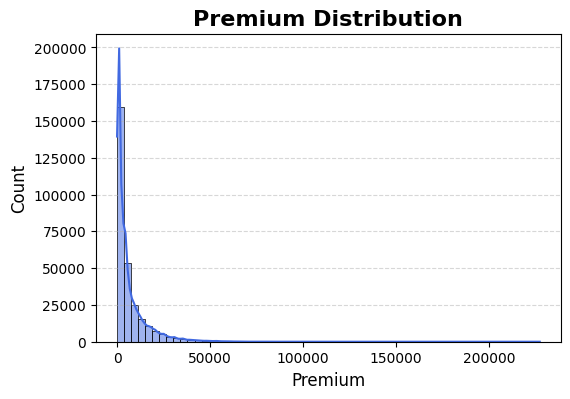

In [149]:
# 1. Premium Distribution

# Plot the distribution of Premium using a histogram with a density curve.
plt.figure(figsize=(6,4))                         # Create a figure
sns.histplot(df['Premium'],
             bins=60, 
             kde = True,
             color='royalblue',
             edgecolor='black')   # Plot histogram with KDE
plt.title("Premium Distribution",fontsize=16, fontweight='bold')
plt.xlabel("Premium", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show() 

#### 2. Claim Amount Distribution

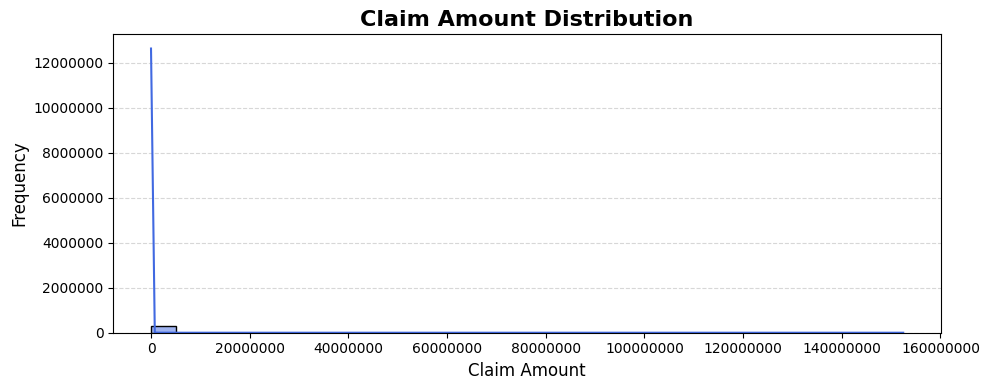

In [146]:
# Create a figure
plt.figure(figsize=(10,4))

# Plot Claim Amount distribution
sns.histplot(df["Claim_Amount"], bins=30, kde=True, color='royalblue')

# Add chart title
plt.title("Claim Amount Distribution", fontsize=16, fontweight='bold')

# Add axis labels
plt.xlabel("Claim Amount", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# Display x-axis values in normal format
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

# Add grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adjust layout
plt.tight_layout()

# Display the chart
plt.show() 

Most policies have no claims.

In [82]:
#3. Vehicle Age Distribution
df["Vehicle_Age"].unique() 

array([ 6,  5,  4,  3,  2,  1, 30, 29,  0, 15, 21,  7, 13, 12, 17, 11, 14,
       18, 16, 28, 27, 20, 19, 39, 38, 10,  9,  8, 25, 24, 23, 34, 33, 32,
       31, 22, 26, 35, 44, 43, 42, 37, 36, 41, 40, 45, 51, 50, 49, 48, 53,
       54, 47, 46, 56, 55, 61, 60, 59, 58, 52, 63, 62, 57, 64],
      dtype=int64)

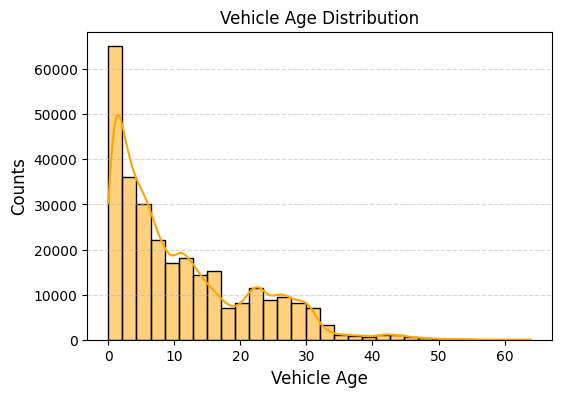

In [138]:
plt.figure(figsize=(6,4))
sns.histplot(df["Vehicle_Age"], 
             bins = 30, 
             kde = True,
             color='orange',
             edgecolor='black')
plt.title("Vehicle Age Distribution")
plt.xlabel("Vehicle Age", fontsize=12)
plt.ylabel("Counts", fontsize=12) 
plt.grid(axis="y", linestyle="--", alpha=0.5)  # Add grid lines
plt.savefig("VehicleAge_DistF.png", dpi=300, bbox_inches='tight')
plt.show() 

#### 4. Brand Distribution

Most insured vehicles are 3–8 years old.

In [ ]:
# Plot the top 10 most frequent vehicle brands.

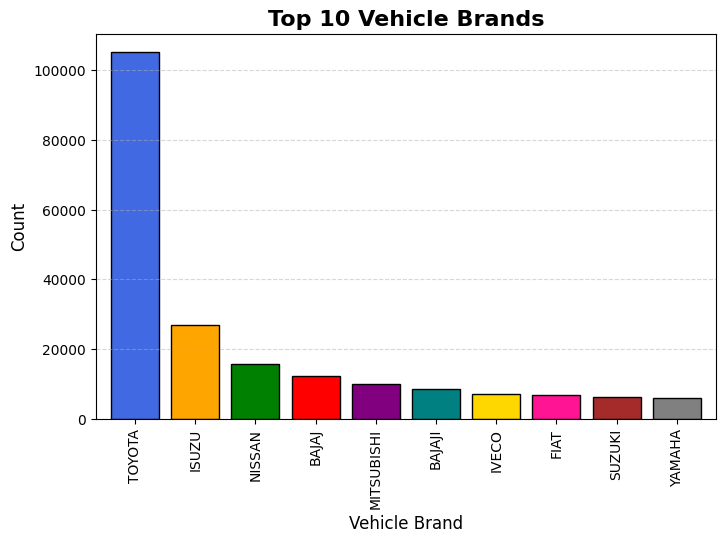

In [133]:
# Create a figure
plt.figure(figsize=(8,5))


df['Brand'].value_counts().head(10).plot(            # Plot the top 10 vehicle brands
    kind='bar',
    color = ['royalblue', 'orange', 'green', 'red', 'purple',
          'teal', 'gold', 'deeppink', 'brown', 'gray'],      # Set bar color
    edgecolor='black',      # Add black border to bars
    width=0.8               # Set bar width
)
plt.title("Top 10 Vehicle Brands", fontsize=16, fontweight='bold') # Add chart title

plt.xlabel("Vehicle Brand", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)  # Add grid lines
plt.savefig("Top10_Brands.png", dpi=300, bbox_inches='tight')
plt.show()                                            # Display the chart

Toyota has the highest number of insured vehicles.

In [85]:
order = df['Vehicle_Types'].value_counts().index

# 5. Vehicle Type Distribution

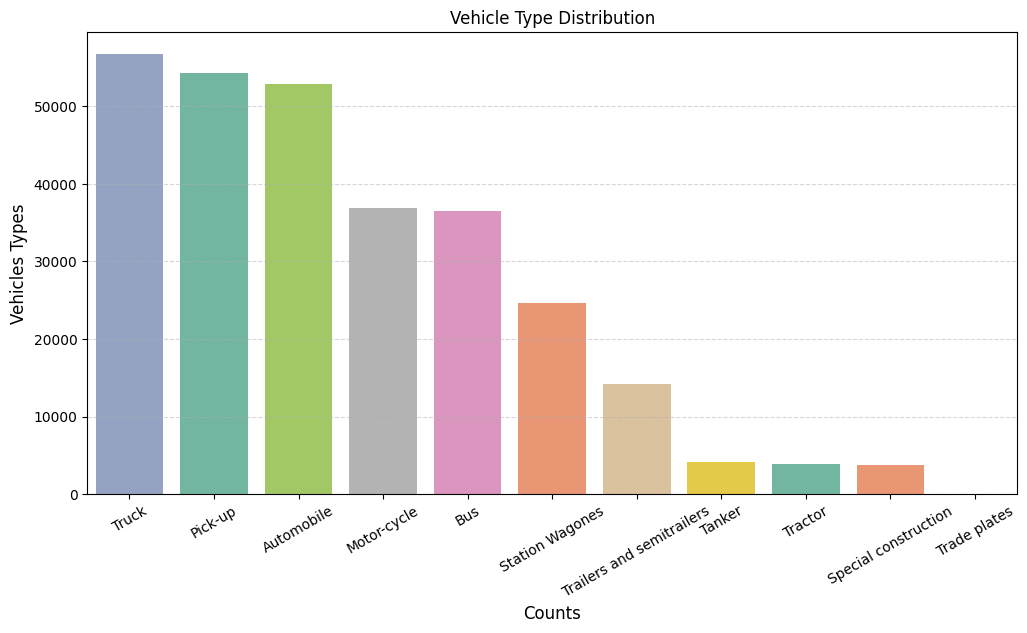

In [164]:
plt.figure(figsize=(12,6))
sns.countplot(data=df,            # Plot the distribution of vehicle types
              x='Vehicle_Types',
              order = order,
              hue='Vehicle_Types',
              palette="Set2") 
plt.xticks(rotation=30)             # Rotate x-axis labels
plt.title("Vehicle Type Distribution") 
plt.grid(axis="y", linestyle="--", alpha=0.5)  # Add grid lines
plt.xlabel("Counts", fontsize=12)
plt.ylabel("Vehicles Types", fontsize=12)
plt.savefig("VehicleTypes_dist.png", dpi=300, bbox_inches='tight') 
plt.show()                       

Pick-up, Truck and Automibile are the most common insured vehicle type.

## BIVARIATE ANALYSIS

In [ ]:
# Premium vs Claim

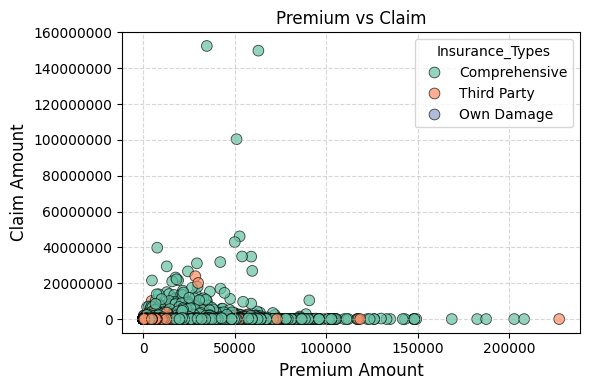

In [137]:
plt.figure(figsize=(6,4))
sns.scatterplot(data = df,
                x = 'Premium',
                y = 'Claim_Amount',
                hue='Insurance_Types',
                palette='Set2',
                s=60,
                alpha=0.7,
                edgecolor='black'
               )
plt.title("Premium vs Claim")
plt.xlabel("Premium Amount", fontsize=12)
plt.ylabel("Claim Amount", fontsize=12) 
plt.grid(linestyle='--', alpha=0.5)
plt.ticklabel_format(style='plain', axis='y') # Display y-axis values in normal format
plt.tight_layout() 
plt.savefig("PremVSClaim.png", dpi=300, bbox_inches='tight')
plt.show()   

In [ ]:
#Brand vs Premium
#df['Brand'].unique()   #There are huge unique value in the column, so its not possiblle

In [99]:
df.head(2) 

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,...,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age,Claim_Ratio,Vehicle_Age_Group,Premium_Category
0,Male,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.14,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim,6,0.0,Medium,Medium
1,Male,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.89,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.0,No Claim,5,0.0,New,Medium


#### Vehicles vs Premium

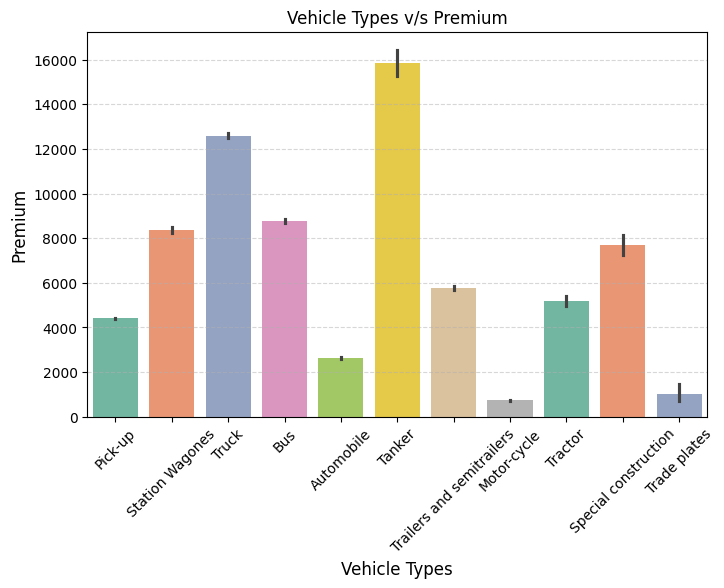

In [151]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,
            x = 'Vehicle_Types',
            y = 'Premium',
            hue='Vehicle_Types',
           palette="Set2") 
plt.xticks(rotation=45) 
plt.title("Vehicle Types v/s Premium") 
plt.grid(axis="y", linestyle="--", alpha=0.5) 
plt.xlabel("Vehicle Types", fontsize=12) 
plt.ylabel("Premium", fontsize=12) 
plt.savefig("VehicleVSPrem.png", dpi=300, bbox_inches='tight')
plt.show()  

Highest premium is Tanker

### Top 10 brand vs claim

In [101]:
df['Claim_Amount'].sum()    

6093514917.89

In [103]:
top10_brands = (
    df.groupby('Brand', as_index=False)['Claim_Amount']
      .sum()
      .sort_values(by='Claim_Amount', ascending=False)
      .head(10)   
) 

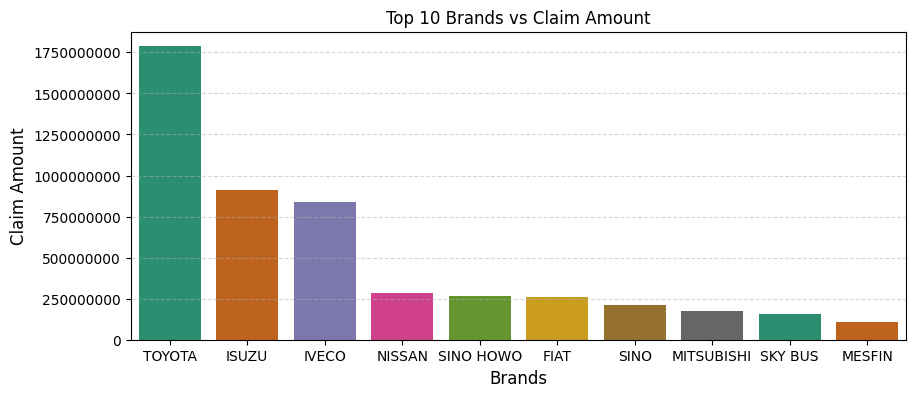

In [152]:
plt.figure(figsize=(10,4))
sns.barplot(data=top10_brands,                  # Plot Top 10 Brands by Claim Amount
            x='Brand',
            y='Claim_Amount',
            hue='Brand',                        # Color bars by brand
            palette="Dark2") 
plt.ticklabel_format(style='plain', axis='y')   # Display y-axis values in normal format
plt.grid(axis="y", linestyle="--", alpha=0.5) 
plt.title("Top 10 Brands vs Claim Amount")   
plt.xlabel("Brands", fontsize=12)              #x-axis
plt.ylabel("Claim Amount", fontsize=12)        #y-axis
plt.savefig("Top10_BrandF.png", dpi=300, bbox_inches='tight')   #save image
plt.show() 

* Toyota has the highest total claim amount among all vehicle brands, followed by Isuzu and Iveco. This indicates that these brands contribute the most to the company's total claim payouts.

In [ ]:
df.head()  

## Usage vs Claim

In [105]:
df['Usage_Types'].unique() 

array(['Own Goods', 'Private', 'General Cartage',
       'Fare Paying Passengers', 'Taxi', 'Car Hires', 'Own service',
       'Agricultural Own Farm', 'Special Construction', 'Others',
       'Learnes', 'Ambulance', 'Agricultural Any Farm', 'Fire fighting'],
      dtype=object)

In [105]:
top5 = (df.groupby("Usage_Types")["Claim_Amount"]
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .reset_index())

In [107]:
top5

,Usage_Types,Claim_Amount
0,General Cartage,2.863089e+09
1,Own Goods,1.159447e+09
2,Fare Paying Passengers,1.097430e+09
3,Private,7.036480e+08
4,Own service,1.702272e+08


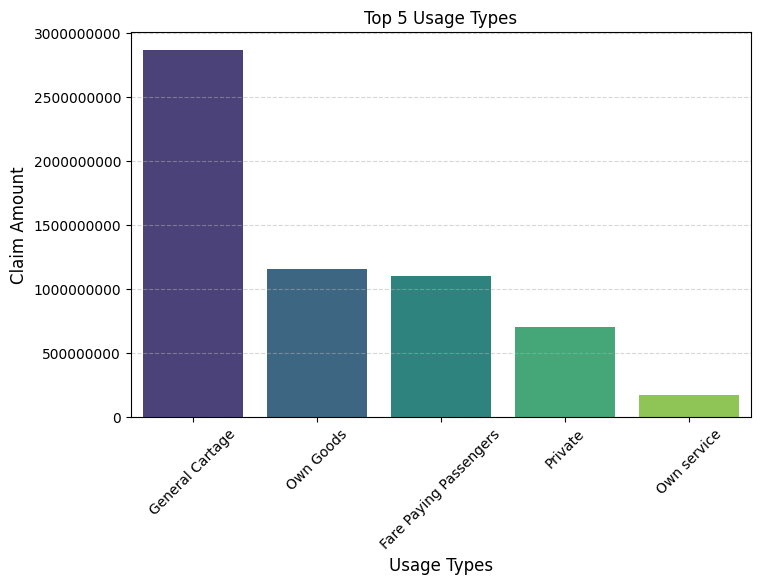

In [153]:
plt.figure(figsize=(8,5))   
sns.barplot(data=top5,
            x='Usage_Types',     #X-axis data
            y='Claim_Amount',    #Y-axis data
            hue='Usage_Types',   # Color bars by brand
            palette="viridis"
           )
plt.title("Top 5 Usage Types")   #Chart title
plt.xticks(rotation=45) 
plt.xlabel("Usage Types", fontsize=12)
plt.ylabel("Claim Amount", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)   #For grid lines
plt.ticklabel_format(style='plain', axis='y')   # Display y-axis values in normal format
plt.savefig("Top5Usage.png", dpi=300, bbox_inches='tight')
plt.show() 

## Vehicle Age vs Claim

In [112]:
df['Vehicle_Age'].dtypes 

dtype('int64')

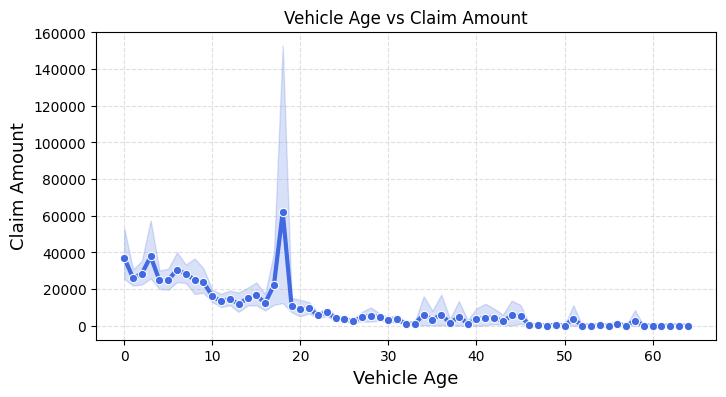

In [154]:
plt.figure(figsize=(8,4))
sns.lineplot(data=df, 
             x='Vehicle_Age',
             y='Claim_Amount',
             marker="o",
             linewidth=3,
             color="royalblue"  
            )
plt.title("Vehicle Age vs Claim Amount")
plt.grid(True, linestyle="--", alpha=0.4)
plt.xlabel("Vehicle Age", fontsize=13)
plt.ylabel("Claim Amount", fontsize=13)
plt.savefig("VehiclAgeClaim.png", dpi=300, bbox_inches='tight') 
plt.show()

In [ ]:
df.head(2) 

### MULTIVARIATE ANALYSIS

### Brand Vehicle Types and Premium 

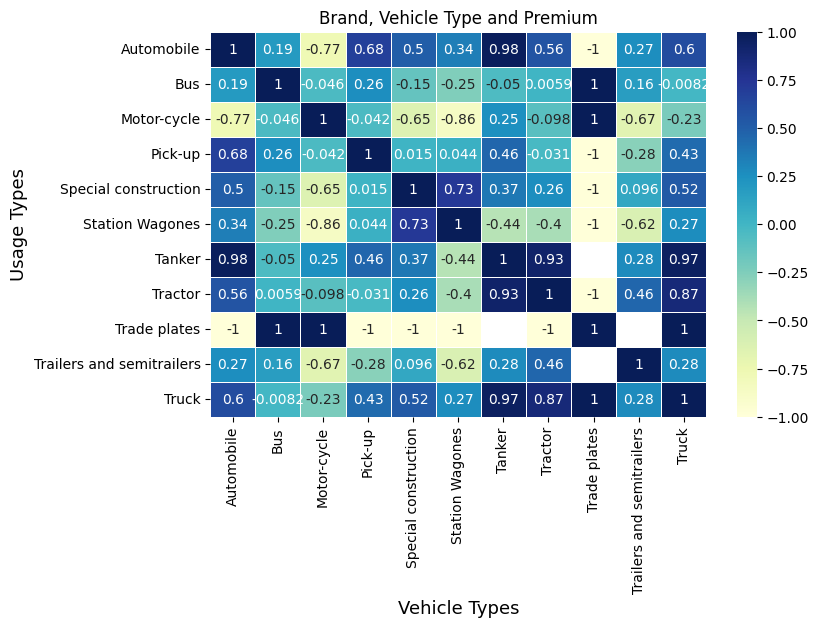

In [155]:
pivot=df.pivot_table(values='Premium',
                       index='Usage_Types',
                       columns='Vehicle_Types',
                       aggfunc='mean')

plt.figure(figsize=(8,5)) 
sns.heatmap(pivot.corr(numeric_only=True),
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5) 
plt.title('Brand, Vehicle Type and Premium') 
plt.xlabel("Vehicle Types", fontsize=13)
plt.ylabel("Usage Types", fontsize=13)
# plt.ticklabel_format(style='plain', axis='y')
plt.savefig("BrandVehicleHeatmap.png", dpi=300, bbox_inches='tight')
plt.show() 

In [132]:
df

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,...,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age,Claim_Ratio,Vehicle_Age_Group,Premium_Category
0,Male,08/08/2013,2013,07/08/2014,2014,1202,519755.22,7209.140,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,6,0.00000,Medium,Medium
1,Male,08/08/2012,2012,07/08/2013,2013,1202,519755.22,7203.890,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,5,0.00000,New,Medium
2,Male,08/08/2011,2011,07/08/2012,2012,1202,519755.22,7045.804,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New,Medium
3,Male,08/07/2011,2011,07/08/2011,2011,1202,519755.22,287.250,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New,Low
4,Male,08/08/2013,2013,07/08/2014,2014,1202,285451.24,4286.900,5000029901,2010,...,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid,3,4.64075,New,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287931,Male,08/07/2011,2011,07/07/2012,2012,1202,100000.00,3673.697,5000051125,2000,...,Station Wagones,4164.0,TOYOTA,Private,0.00,No Claim,11,0.00000,Old,Low
287932,Unknown,11/08/2013,2013,10/08/2014,2014,1201,0.00,541.950,5000047311,1985,...,Automobile,1295.0,TOYOTA,Private,0.00,No Claim,28,0.00000,Old,Low
287933,Unknown,11/08/2012,2012,10/08/2013,2013,1201,0.00,577.700,5000047311,1985,...,Automobile,1295.0,TOYOTA,Private,0.00,No Claim,27,0.00000,Old,Low
287934,Unknown,11/08/2011,2011,10/08/2012,2012,1201,0.00,695.318,5000047311,1985,...,Automobile,1295.0,TOYOTA,Private,0.00,No Claim,26,0.00000,Old,Low


In [119]:
df['Gender'].unique()

array(['Male', 'Female', 'Unknown'], dtype=object)

#### Vehicle Age vs Claim Category

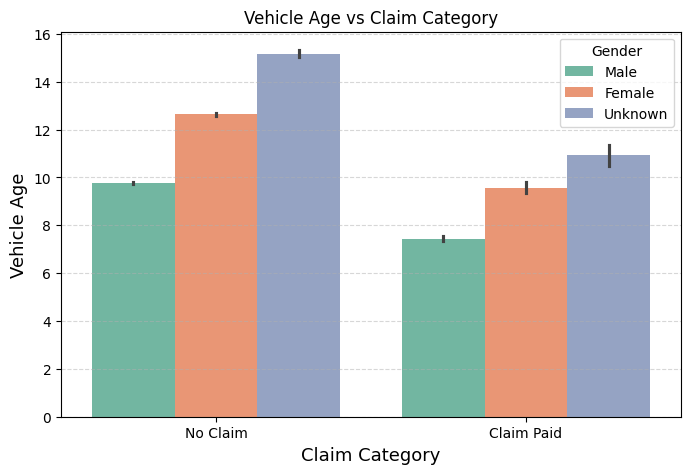

In [158]:
plt.figure(figsize=(8,5))

# Plot Vehicle Age by Claim Category
sns.barplot(data=df,
            x='Claim_Category',
            y='Vehicle_Age',
            hue='Gender',                      # Color bars by gender
            palette="Set2")                    # Set color palette
plt.title('Vehicle Age vs Claim Category')   
plt.legend(title="Gender")
plt.grid(axis="y", linestyle="--", alpha=0.5)  # Add grid lines
plt.xlabel("Claim Category", fontsize=13)
plt.ylabel("Vehicle Age", fontsize=13)
plt.savefig("AgeVSClaim.png", dpi=300, bbox_inches='tight')
plt.show() 

#### Usage Types vs Claim Category

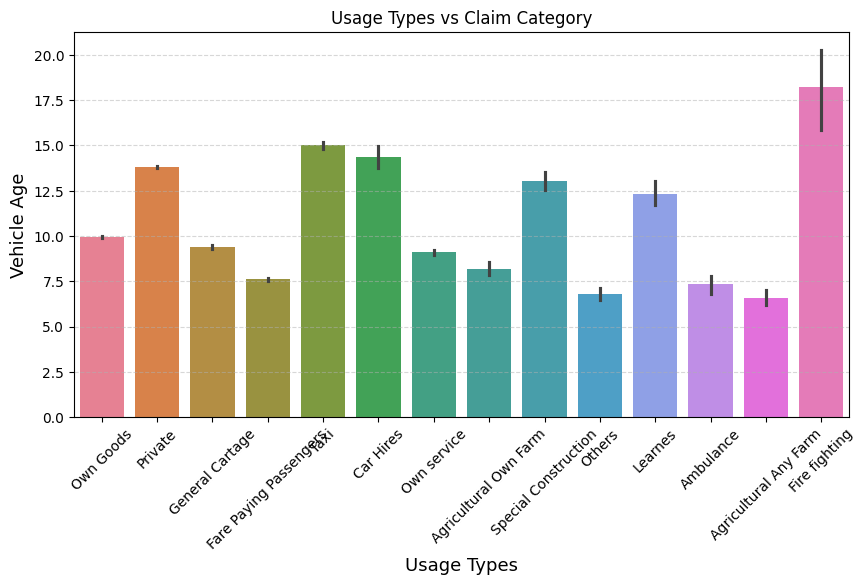

In [159]:
plt.figure(figsize=(10,5))
sns.barplot(data=df,
            x='Usage_Types',
            y='Vehicle_Age',hue='Usage_Types')
plt.title('Usage Types vs Claim Category')
plt.grid(axis="y", linestyle="--", alpha=0.5)  # Add grid lines
#plt.legend(title="Gender")    
plt.xticks(rotation=45) 
plt.xlabel("Usage Types", fontsize=13)
plt.ylabel("Vehicle Age", fontsize=13) 
plt.savefig("UsageTypeClaim.png", dpi=300, bbox_inches='tight')
plt.show() 

#### Vehicle Age vs Claim Category

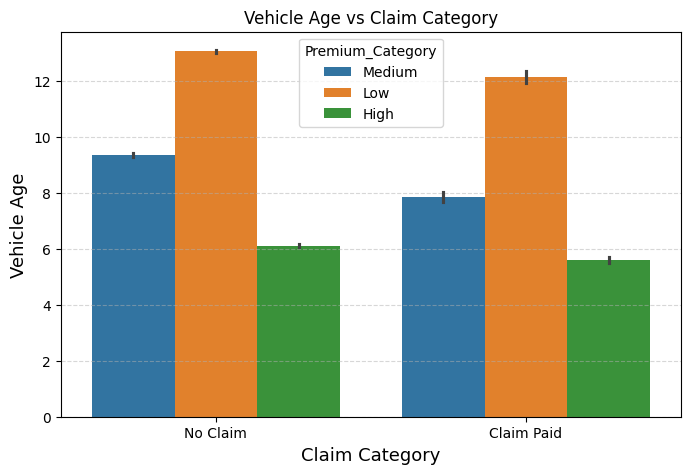

In [160]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,
            x='Claim_Category',
            y='Vehicle_Age',
            hue='Premium_Category'  #Category wise color
           )
plt.title('Vehicle Age vs Claim Category')
plt.legend(title="Premium_Category")
plt.grid(axis="y", linestyle="--", alpha=0.5)  # Add grid lines
plt.xlabel("Claim Category", fontsize=13)
plt.ylabel("Vehicle Age", fontsize=13)
plt.savefig("VehicleAgeVSClaimCategory.png", dpi=300, bbox_inches='tight')
plt.show() 

## PART-4 Correlation

In [ ]:
df.head()

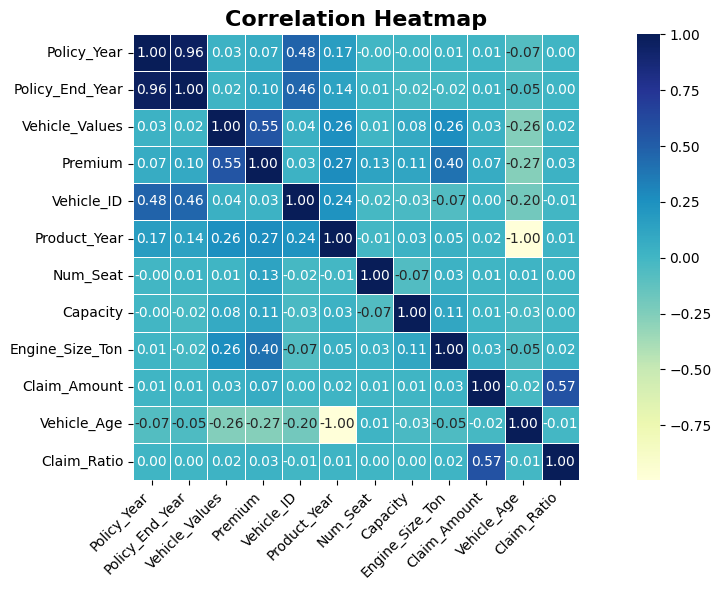

In [161]:
plt.figure(figsize=(12,6))  # Create a figure

# Plot correlation heatmap
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,           # Show correlation values
    cmap='YlGnBu',        # Set color palette
    fmt='.2f',            # Display values up to 2 decimals
    linewidths=0.5,       # Add cell borders
    linecolor='white',    # Set border color
    square=True,          # Make cells square
    cbar=True,            # Show color bar
    annot_kws={"size": 10}
)
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold') # Add chart title

plt.xticks(rotation=45, ha='right')   # Rotate axis labels
plt.yticks(rotation=0)

plt.tight_layout()  # Adjust layout
plt.savefig("Correlation.png", dpi=300, bbox_inches='tight')  #Save image
plt.show()  

### PART-5 Outlier Analysis

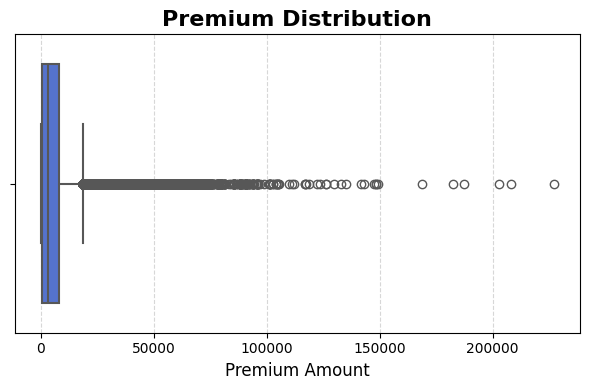

In [162]:
# Create a figure
plt.figure(figsize=(6,4))

# Plot Premium boxplot
sns.boxplot(
    x=df['Premium'],
    color='royalblue',     # Set box color
    linewidth=1.5          # Set box border width
)

plt.title("Premium Distribution", fontsize=16, fontweight='bold' )  # Add chart title

plt.xlabel("Premium Amount", fontsize=12)  # Add x-axis label
 
plt.grid(axis='x', linestyle='--', alpha=0.5) # Add grid lines
plt.tight_layout()        # Adjust layout
plt.savefig("PremiumDist.png", dpi=300, bbox_inches='tight')
plt.show()                # Display the chart

In [ ]:
df.head(2) 

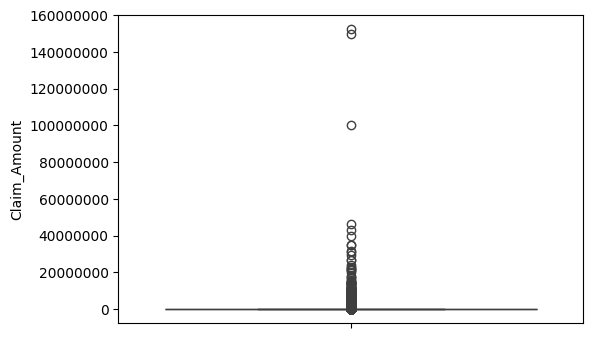

In [120]:
plt.figure(figsize=(6,4)) 

sns.boxplot(df['Claim_Amount'])
plt.ticklabel_format(style='plain', axis='y')  
plt.show() 

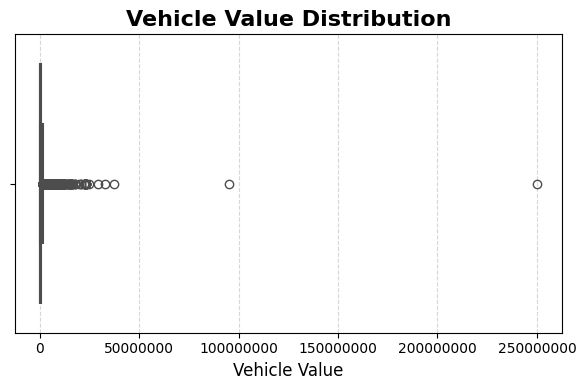

In [163]:
# Create a figure
plt.figure(figsize=(6,4))

# Plot Vehicle Value boxplot
sns.boxplot(
    x=df['Vehicle_Values'],
      color='orange',          # Set box color
    linewidth=1.5          # Set box border width
)

# Display x-axis values in normal format
plt.ticklabel_format(style='plain', axis='x')

# Add chart title
plt.title("Vehicle Value Distribution", fontsize=16, fontweight='bold')

# Add x-axis label
plt.xlabel("Vehicle Value", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5) # Add grid lines

plt.tight_layout()
plt.savefig("VehicleDistribution.png", dpi=300, bbox_inches='tight')
plt.show()   # Display the chart

In [ ]:
# Save the cleaned CSV file
df.to_csv("Vehicle_Insurance.csv",index=False) 

In [ ]:
df.to_csv("Motor_Insurance.csv",index=False) 

In [123]:
df.head()

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,...,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age,Claim_Ratio,Vehicle_Age_Group,Premium_Category
0,Male,08/08/2013,2013,07/08/2014,2014,Comprehensive,519755.22,7209.140,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,6,0.00000,Medium,Medium
1,Male,08/08/2012,2012,07/08/2013,2013,Comprehensive,519755.22,7203.890,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,5,0.00000,New,Medium
2,Male,08/08/2011,2011,07/08/2012,2012,Comprehensive,519755.22,7045.804,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New,Medium
3,Male,08/07/2011,2011,07/08/2011,2011,Comprehensive,519755.22,287.250,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New,Low
4,Male,08/08/2013,2013,07/08/2014,2014,Comprehensive,285451.24,4286.900,5000029901,2010,...,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid,3,4.64075,New,Low


In [ ]:
df

In [ ]:
df1 = df.copy() 

In [ ]:
df.head(2)

In [122]:
df

,Gender,Policy_Start,Policy_Year,Policy_End,Policy_End_Year,Insurance_Types,Vehicle_Values,Premium,Vehicle_ID,Product_Year,...,Vehicle_Types,Engine_Size_Ton,Brand,Usage_Types,Claim_Amount,Claim_Category,Vehicle_Age,Claim_Ratio,Vehicle_Age_Group,Premium_Category
0,Male,08/08/2013,2013,07/08/2014,2014,Comprehensive,519755.22,7209.140,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,6,0.00000,Medium,Medium
1,Male,08/08/2012,2012,07/08/2013,2013,Comprehensive,519755.22,7203.890,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,5,0.00000,New,Medium
2,Male,08/08/2011,2011,07/08/2012,2012,Comprehensive,519755.22,7045.804,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New,Medium
3,Male,08/07/2011,2011,07/08/2011,2011,Comprehensive,519755.22,287.250,5000029885,2007,...,Pick-up,3153.0,NISSAN,Own Goods,0.00,No Claim,4,0.00000,New,Low
4,Male,08/08/2013,2013,07/08/2014,2014,Comprehensive,285451.24,4286.900,5000029901,2010,...,Pick-up,2494.0,TOYOTA,Own Goods,19894.43,Claim Paid,3,4.64075,New,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287931,Male,08/07/2011,2011,07/07/2012,2012,Comprehensive,100000.00,3673.697,5000051125,2000,...,Station Wagones,4164.0,TOYOTA,Private,0.00,No Claim,11,0.00000,Old,Low
287932,Unknown,11/08/2013,2013,10/08/2014,2014,Third Party,0.00,541.950,5000047311,1985,...,Automobile,1295.0,TOYOTA,Private,0.00,No Claim,28,0.00000,Old,Low
287933,Unknown,11/08/2012,2012,10/08/2013,2013,Third Party,0.00,577.700,5000047311,1985,...,Automobile,1295.0,TOYOTA,Private,0.00,No Claim,27,0.00000,Old,Low
287934,Unknown,11/08/2011,2011,10/08/2012,2012,Third Party,0.00,695.318,5000047311,1985,...,Automobile,1295.0,TOYOTA,Private,0.00,No Claim,26,0.00000,Old,Low


In [87]:
df.to_csv("insurance.csv",index=False) 